In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 한글 표시
plt.rcParams['font.family'] = "Gulim"
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 데이터 로드
df_merged = pd.read_csv('df_merged.csv')
y_targets = pd.read_csv('y_targets.csv')

In [4]:
# 기본 정보
months = df_merged['month'].values
scenarios = df_merged['scenario'].values

In [6]:
environmental = ['CO2ppm', 'Temp', 'Humid', 'VPD']
physiological = ['Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car']
fluorescence = ['ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']

In [7]:
# 원본 특성
original_features = environmental + physiological + fluorescence
X_original = df_merged[original_features].copy()

### 전처리

In [8]:
# 엔지니어링된 특성 추가
X_engineered = X_original.copy()

In [9]:
# 1. 생육 단계 (월별)
growth_map = {5: 1, 6: 2, 7: 3, 8: 4, 9: 5}
X_engineered['growth_stage'] = [growth_map[m] for m in months]
X_engineered['growth_stage_sq'] = X_engineered['growth_stage'] ** 2

In [10]:
# 2. 시나리오 정보 (중요!)
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    X_engineered[f'is_{scenario}'] = (scenarios == scenario).astype(int)

In [11]:
# 3. 온도 스트레스 (천궁 최적 온도 15-25°C)
X_engineered['temp_stress'] = np.abs(X_engineered['Temp'] - 22)
X_engineered['temp_optimal'] = 1 / (1 + X_engineered['temp_stress'])

In [12]:
# 4. VPD 스트레스
X_engineered['vpd_stress'] = np.where(X_engineered['VPD'] > 1.5, X_engineered['VPD'] - 1.5, 0)

In [13]:
# 5. CO2 효과
X_engineered['co2_effect'] = np.log1p(X_engineered['CO2ppm'] / 400)

In [14]:
# 6. 광합성 효율
X_engineered['photosyn_efficiency'] = X_engineered['PI_abs'] * X_engineered['Fv-Fm']
X_engineered['energy_dissipation'] = X_engineered['Dio-RC'] / (X_engineered['ABS-RC'] + 1e-10)

In [15]:
# 7. 시나리오별 상호작용 특성
X_engineered['temp_x_ssp5'] = X_engineered['Temp'] * X_engineered['is_SSP5']
X_engineered['co2_x_ssp5'] = X_engineered['CO2ppm'] * X_engineered['is_SSP5']

### MAPE 계산 함수

In [16]:
def calculate_mape(y_true, y_pred, eps=1e-9):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

### 성능 지표 계산

In [17]:
# 포괄적 성능 지표 계산
def calculate_comprehensive_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # MSLE, RMSLE
    y_true_pos = np.maximum(y_true, 0)
    y_pred_pos = np.maximum(y_pred, 0)
    msle = mean_squared_error(np.log1p(y_true_pos), np.log1p(y_pred_pos))
    rmsle = np.sqrt(msle)
    
    r2 = r2_score(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MSLE': msle,
        'RMSLE': rmsle,
        'R2': r2,
        'MAPE': mape
    }

### 모델링

In [18]:
# 최적화된 모델 정의
models = {
    'LinearR': LinearRegression(),
    
    'kNN': KNeighborsRegressor(
        n_neighbors=7,
        weights='distance',
        metric='minkowski',
        p=2
    ),
    
    'SVM': SVR(
        kernel='rbf',
        C=3.0,
        epsilon=0.05,
        gamma='scale'
    ),
    
    'DT': DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ),
    
    'RF': RandomForestRegressor(
        n_estimators=800,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ),
    
    'GB': GradientBoostingRegressor(
        n_estimators=400,
        max_depth=7,
        learning_rate=0.08,
        subsample=0.85,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ),
    
    'XGB': xgb.XGBRegressor(
        n_estimators=600,
        max_depth=9,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        colsample_bylevel=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=2,
        gamma=0.1,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        verbose=0
    ),
    
    'LGBM': lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=12,
        learning_rate=0.05,
        num_leaves=64,
        min_child_samples=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.5,
        min_split_gain=0.01,
        feature_fraction=0.8,
        bagging_fraction=0.85,
        bagging_freq=5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

In [19]:
# 네이티브 다중출력 지원 모델
NATIVE_MULTIOUTPUT = ['RF', 'DT', 'kNN']

In [20]:
# 결과 저장
scenario_results_orig = {}
scenario_results_eng = {}

# 시나리오별 개별 모델링
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n=== {scenario} 시나리오 모델링 ===")
    
    # 해당 시나리오 데이터만 추출
    scenario_mask = scenarios == scenario
    X_scenario_orig = X_original[scenario_mask]
    X_scenario_eng = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    print(f"시나리오 데이터: {len(y_scenario)} samples")
    
    # 80/20 분할
    X_tr_orig, X_te_orig, X_tr_eng, X_te_eng, y_tr, y_te = train_test_split(
        X_scenario_orig, X_scenario_eng, y_scenario,
        test_size=0.2, random_state=42
    )
    
    print(f"Train: {len(y_tr)}, Test: {len(y_te)}")
    
    # 스케일링
    sc_orig = RobustScaler()
    X_tr_orig_scaled = sc_orig.fit_transform(X_tr_orig)
    X_te_orig_scaled = sc_orig.transform(X_te_orig)
    
    sc_eng = RobustScaler()
    X_tr_eng_scaled = sc_eng.fit_transform(X_tr_eng)
    X_te_eng_scaled = sc_eng.transform(X_te_eng)
    
    scenario_results_orig[scenario] = {}
    scenario_results_eng[scenario] = {}
    
    best_mae = float('inf')
    best_model = None
    
    for model_name, base_model in models.items():
        from sklearn.base import clone
        model_orig = clone(base_model)
        model_eng = clone(base_model)
        
        if model_name not in NATIVE_MULTIOUTPUT:
            model_orig = MultiOutputRegressor(model_orig)
            model_eng = MultiOutputRegressor(model_eng)
        
        try:
            # Original data
            model_orig.fit(X_tr_orig_scaled, y_tr)
            pred_orig = model_orig.predict(X_te_orig_scaled)
            met_orig = calculate_comprehensive_metrics(y_te, pred_orig)
            scenario_results_orig[scenario][model_name] = met_orig
            
            # Engineered data
            model_eng.fit(X_tr_eng_scaled, y_tr)
            pred_eng = model_eng.predict(X_te_eng_scaled)
            met_eng = calculate_comprehensive_metrics(y_te, pred_eng)
            scenario_results_eng[scenario][model_name] = met_eng
            
            # 최고 성능 모델 추적
            if met_eng['MAE'] < best_mae:
                best_mae = met_eng['MAE']
                best_model = model_name
                
        except Exception as e:
            print(f"  {model_name} 오류: {e}")
    
    print(f"🏆 최고 성능: {best_model} - MAE: {best_mae:.4f}, MAPE: {scenario_results_eng[scenario][best_model]['MAPE']:.2f}%, R2: {scenario_results_eng[scenario][best_model]['R2']:.4f}")


=== SSP1 시나리오 모델링 ===
시나리오 데이터: 135 samples
Train: 108, Test: 27
🏆 최고 성능: LGBM - MAE: 0.0693, MAPE: 1.69%, R2: 0.9721

=== SSP3 시나리오 모델링 ===
시나리오 데이터: 135 samples
Train: 108, Test: 27
🏆 최고 성능: DT - MAE: 0.0566, MAPE: 1.30%, R2: 0.9744

=== SSP5 시나리오 모델링 ===
시나리오 데이터: 135 samples
Train: 108, Test: 27
🏆 최고 성능: DT - MAE: 0.0326, MAPE: 0.70%, R2: 0.9532


### 데이터 테이블 생성

In [21]:
# Original Data 테이블
print("\n=== Original Data Results ===")
print("=" * 130)
print(f"{'Data':<15} {'Model':<10} {'SSP1-2.6':^35} {'SSP3-7.0':^35} {'SSP5-8.5':^35}")
print(f"{'':^15} {'':^10} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12}")
print("=" * 130)

for model_name in models.keys():
    if model_name in scenario_results_orig['SSP1']:
        row = f"{'Original':<15} {model_name:<10}"
        for scenario in ['SSP1', 'SSP3', 'SSP5']:
            metrics = scenario_results_orig[scenario][model_name]
            row += f" {metrics['MAE']:<11.3f} {metrics['RMSE']:<11.3f} {metrics['MAPE']:<11.3f}"
        print(row)


=== Original Data Results ===
Data            Model                   SSP1-2.6                            SSP3-7.0                            SSP5-8.5              
                           MAE          RMSE         MAPE         MAE          RMSE         MAPE         MAE          RMSE         MAPE        
Original        LinearR    0.264       0.473       8.448       0.224       0.399       6.148       0.252       0.538       8.073      
Original        kNN        0.076       0.132       1.784       0.119       0.291       3.585       0.161       0.566       5.359      
Original        SVM        0.124       0.233       3.848       0.222       0.524       7.123       0.270       0.897       10.168     
Original        DT         0.066       0.123       1.381       0.056       0.093       1.280       0.034       0.062       0.885      
Original        RF         0.072       0.123       1.664       0.064       0.093       1.680       0.046       0.085       1.221      
Original       

In [22]:
# Engineered Data 테이블
print("\n=== Engineered Data Results ===")
print("=" * 130)
print(f"{'Data':<15} {'Model':<10} {'SSP1-2.6':^35} {'SSP3-7.0':^35} {'SSP5-8.5':^35}")
print(f"{'':^15} {'':^10} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12}")
print("=" * 130)

for model_name in models.keys():
    if model_name in scenario_results_eng['SSP1']:
        row = f"{'Engineered':<15} {model_name:<10}"
        for scenario in ['SSP1', 'SSP3', 'SSP5']:
            metrics = scenario_results_eng[scenario][model_name]
            row += f" {metrics['MAE']:<11.3f} {metrics['RMSE']:<11.3f} {metrics['MAPE']:<11.3f}"
        print(row)


=== Engineered Data Results ===
Data            Model                   SSP1-2.6                            SSP3-7.0                            SSP5-8.5              
                           MAE          RMSE         MAPE         MAE          RMSE         MAPE         MAE          RMSE         MAPE        
Engineered      LinearR    0.138       0.254       3.353       0.113       0.167       3.078       0.077       0.138       1.718      
Engineered      kNN        0.083       0.147       1.988       0.117       0.278       3.171       0.175       0.562       6.358      
Engineered      SVM        0.111       0.195       3.674       0.189       0.489       5.514       0.239       0.783       9.107      
Engineered      DT         0.146       0.528       4.328       0.057       0.112       1.298       0.033       0.053       0.697      
Engineered      RF         0.072       0.128       1.662       0.063       0.092       1.608       0.040       0.066       0.955      
Engineered   

In [23]:
# 전체 성능 지표 테이블 (MAE, MSE, RMSE, MSLE, RMSLE, R2)
print("\n=== 전체 성능 지표 (Engineered Data) ===")
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n{scenario} 시나리오:")
    print("-" * 100)
    print(f"{'Model':<10} {'MAE':<10} {'MSE':<10} {'RMSE':<10} {'MSLE':<10} {'RMSLE':<10} {'R2':<10} {'MAPE(%)':<10}")
    print("-" * 100)
    
    for model_name in models.keys():
        if model_name in scenario_results_eng[scenario]:
            m = scenario_results_eng[scenario][model_name]
            print(f"{model_name:<10} {m['MAE']:<10.4f} {m['MSE']:<10.4f} {m['RMSE']:<10.4f} "
                  f"{m['MSLE']:<10.4f} {m['RMSLE']:<10.4f} {m['R2']:<10.4f} {m['MAPE']:<10.2f}")


=== 전체 성능 지표 (Engineered Data) ===

SSP1 시나리오:
----------------------------------------------------------------------------------------------------
Model      MAE        MSE        RMSE       MSLE       RMSLE      R2         MAPE(%)   
----------------------------------------------------------------------------------------------------
LinearR    0.1385     0.0646     0.2542     0.0018     0.0428     0.9536     3.35      
kNN        0.0834     0.0217     0.1474     0.0007     0.0268     0.9643     1.99      
SVM        0.1108     0.0380     0.1950     0.0013     0.0367     0.9499     3.67      
DT         0.1464     0.2790     0.5283     0.0094     0.0967     0.8837     4.33      
RF         0.0723     0.0163     0.1279     0.0005     0.0231     0.9738     1.66      
GB         0.0773     0.0167     0.1292     0.0004     0.0200     0.9647     1.71      
XGB        0.1136     0.0452     0.2126     0.0011     0.0329     0.8846     3.37      
LGBM       0.0693     0.0137     0.1170     0.

### 특성 중요도 분석(시나리오별 분석)

In [24]:
feature_importance_by_scenario = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_mask = scenarios == scenario
    X_scenario = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    # RandomForest로 특성 중요도 계산
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_scenario, y_scenario)
    
    if hasattr(rf, 'feature_importances_'):
        importance = rf.feature_importances_
    else:
        importance = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
    
    feature_importance_by_scenario[scenario] = importance
    
    # 상위 5개 특성
    top_indices = np.argsort(importance)[-5:][::-1]
    print(f"\n{scenario} Top 5 특성:")
    for idx in top_indices:
        print(f"  {X_engineered.columns[idx]:20s}: {importance[idx]:.4f}")


SSP1 Top 5 특성:
  growth_stage        : 0.4923
  growth_stage_sq     : 0.4219
  temp_stress         : 0.0110
  temp_optimal        : 0.0097
  Humid               : 0.0093

SSP3 Top 5 특성:
  growth_stage        : 0.5087
  growth_stage_sq     : 0.3993
  Tro-RC              : 0.0083
  ABS-RC              : 0.0078
  SFI_abs             : 0.0078

SSP5 Top 5 특성:
  growth_stage        : 0.3872
  Dio-RC              : 0.2952
  growth_stage_sq     : 0.2178
  Humid               : 0.0160
  Chl_a               : 0.0143


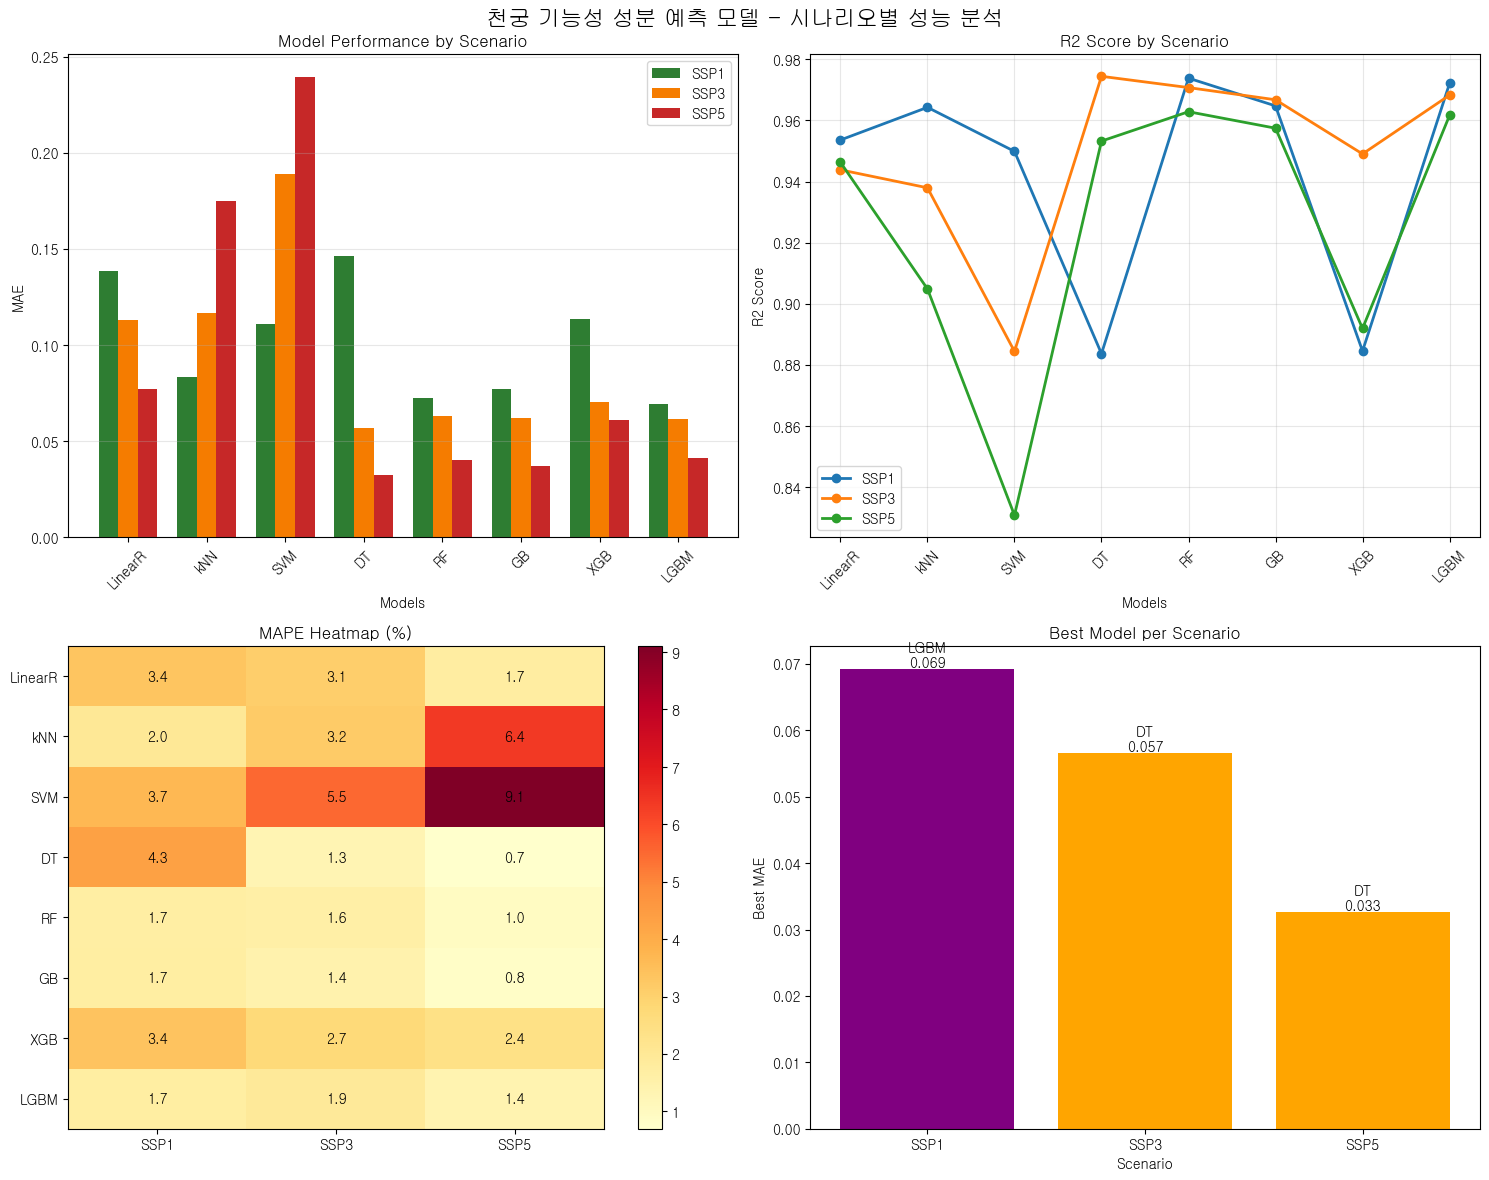

In [25]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 모델별 MAE 비교
ax = axes[0, 0]
x = np.arange(len(models))
width = 0.25
colors = ['#2E7D32', '#F57C00', '#C62828']

for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    mae_values = [scenario_results_eng[scenario][model]['MAE'] for model in models.keys()]
    ax.bar(x + i*width, mae_values, width, label=scenario, color=colors[i])

ax.set_xlabel('Models')
ax.set_ylabel('MAE')
ax.set_title('Model Performance by Scenario')
ax.set_xticks(x + width)
ax.set_xticklabels(models.keys(), rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. R2 Score 비교
ax = axes[0, 1]
for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    r2_values = [scenario_results_eng[scenario][model]['R2'] for model in models.keys()]
    ax.plot(models.keys(), r2_values, marker='o', label=scenario, linewidth=2)

ax.set_xlabel('Models')
ax.set_ylabel('R2 Score')
ax.set_title('R2 Score by Scenario')
ax.set_xticklabels(models.keys(), rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. MAPE 히트맵
ax = axes[1, 0]
mape_matrix = []
for model in models.keys():
    row = [scenario_results_eng[scenario][model]['MAPE'] for scenario in ['SSP1', 'SSP3', 'SSP5']]
    mape_matrix.append(row)

im = ax.imshow(mape_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(3))
ax.set_xticklabels(['SSP1', 'SSP3', 'SSP5'])
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models.keys())
ax.set_title('MAPE Heatmap (%)')
plt.colorbar(im, ax=ax)

for i in range(len(models)):
    for j in range(3):
        text = ax.text(j, i, f'{mape_matrix[i][j]:.1f}',
                      ha="center", va="center", color="black")

# 4. 최적 모델 선택
ax = axes[1, 1]
best_models = []
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(scenario_results_eng[scenario].items(), key=lambda x: x[1]['MAE'])
    best_models.append((scenario, best[0], best[1]['MAE']))

scenarios_list = [x[0] for x in best_models]
models_list = [x[1] for x in best_models]
mae_list = [x[2] for x in best_models]

colors_map = {'RF': 'green', 'GB': 'blue', 'XGB': 'red', 'LGBM': 'purple', 
              'DT': 'orange', 'kNN': 'brown', 'SVM': 'pink', 'LinearR': 'gray'}
colors_plot = [colors_map.get(m, 'black') for m in models_list]

bars = ax.bar(scenarios_list, mae_list, color=colors_plot)
ax.set_xlabel('Scenario')
ax.set_ylabel('Best MAE')
ax.set_title('Best Model per Scenario')

for i, (scenario, model, mae) in enumerate(best_models):
    ax.text(i, mae, f'{model}\n{mae:.3f}', ha='center', va='bottom')

plt.suptitle('천궁 기능성 성분 예측 모델 - 시나리오별 성능 분석', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
print("\n시나리오별 최고 성능 모델:")
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(scenario_results_eng[scenario].items(), key=lambda x: x[1]['MAE'])
    print(f"{scenario}: {best[0]} (MAE={best[1]['MAE']:.4f}, R2={best[1]['R2']:.4f}, MAPE={best[1]['MAPE']:.2f}%)")


시나리오별 최고 성능 모델:
SSP1: LGBM (MAE=0.0693, R2=0.9721, MAPE=1.69%)
SSP3: DT (MAE=0.0566, R2=0.9744, MAPE=1.30%)
SSP5: DT (MAE=0.0326, R2=0.9532, MAPE=0.70%)


In [27]:
# 평균 성능
print("\n모델별 평균 성능 (3개 시나리오):")
model_avg = {}
for model_name in models.keys():
    mae_list = [scenario_results_eng[scenario][model_name]['MAE'] for scenario in ['SSP1', 'SSP3', 'SSP5']]
    r2_list = [scenario_results_eng[scenario][model_name]['R2'] for scenario in ['SSP1', 'SSP3', 'SSP5']]
    mape_list = [scenario_results_eng[scenario][model_name]['MAPE'] for scenario in ['SSP1', 'SSP3', 'SSP5']]
    
    model_avg[model_name] = {
        'MAE': np.mean(mae_list),
        'R2': np.mean(r2_list),
        'MAPE': np.mean(mape_list)
    }

sorted_models = sorted(model_avg.items(), key=lambda x: x[1]['MAE'])
for model, metrics in sorted_models[:5]:
    print(f"{model}: MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}, MAPE={metrics['MAPE']:.2f}%")


모델별 평균 성능 (3개 시나리오):
LGBM: MAE=0.0574, R2=0.9673, MAPE=1.67%
RF: MAE=0.0585, R2=0.9691, MAPE=1.41%
GB: MAE=0.0589, R2=0.9630, MAPE=1.32%
DT: MAE=0.0785, R2=0.9371, MAPE=2.11%
XGB: MAE=0.0816, R2=0.9085, MAPE=2.82%
